# Logistic Regression from Scratch

Binary classification predicting **obesity from body weight (grams)** in rats, using a logistic regression model implemented from scratch with gradient descent (NumPy only), then evaluated with scikit-learn metrics.

## Imports

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

## Load Dataset

In [ ]:
# 290, 330, 350 are held out for testing; the rest are for training.
# No point appears in both sets (avoids data leakage).
X_train = np.array([
    [250],
    [270],
    [310],
    [370],
    [390],
    [410]
])
y_train = np.array([0, 0, 0, 1, 1, 1])


X_test = np.array([
    [290],
    [330],
    [350]
])

y_test = np.array([0, 1, 1])

# Standardize features using TRAIN statistics only.
# Large raw values (250-410) make the gradients explode, so the
# loss oscillates instead of converging. Scaling fixes that.
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_train = (X_train - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

In [11]:
class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.001, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y, y_pred):
        return -np.mean(
            y * np.log(y_pred + 1e-15) +
            (1 - y) * np.log(1 - y_pred + 1e-15)
        )

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):

            z = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(z)

            loss = self.compute_loss(y, y_pred)

            self.loss_history.append(loss)

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            if epoch % 100 == 0:
                print(f"Epoch {epoch}: Loss = {loss:.4f}")

    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)

    def predict(self, X):
        probs = self.predict_proba(X)
        return (probs >= 0.5).astype(int)


model =  LogisticRegressionScratch(learning_rate = 0.01, epochs = 1000)      
model.fit(X_train, y_train)

Epoch 0: Loss = 0.6931
Epoch 100: Loss = 0.5198
Epoch 200: Loss = 0.4116
Epoch 300: Loss = 0.3404
Epoch 400: Loss = 0.2909
Epoch 500: Loss = 0.2548
Epoch 600: Loss = 0.2274
Epoch 700: Loss = 0.2059
Epoch 800: Loss = 0.1885
Epoch 900: Loss = 0.1742


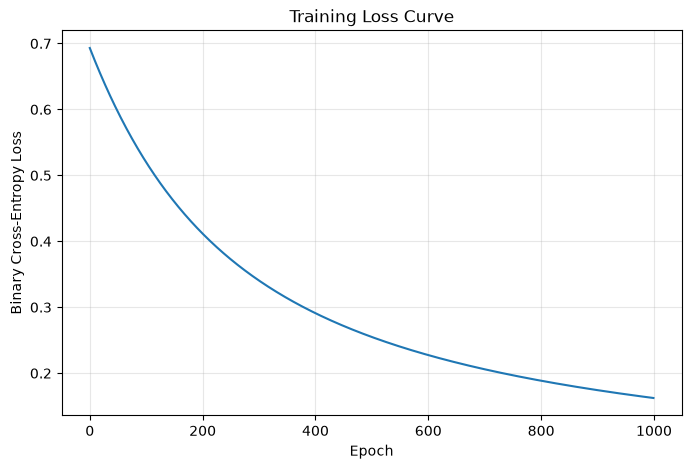

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(model.loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.show()

## Evaluation Metrics

In [7]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"ROC AUC    : {roc_auc_score(y_test, y_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy   : 0.6667
Precision  : 1.0000
Recall     : 0.5000
F1 Score   : 0.6667
ROC AUC    : 1.0000

Confusion Matrix:
[[1 0]
 [1 1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3

